In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import utils
import storm_dates
import pre_processing
import constants
import matplotlib.dates as mdates
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

/mnt/data/symbolic-regression-dst-public-repo/.venv/lib/python3.12/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


In [3]:
relevant_columns = ['Bz', 'Vp', 'Np', 'T', 'Bmag']

In [ ]:
ace_columns = ['Bmag', 'Bx', 'By', 'Bz','Vp', 'Np', 'T']

dst_kyoto = utils.read_iaga_file('./data/dst-kyoto.txt', columns = ["DATE", "TIME", "DOY", "DST"])
dst_kyoto = dst_kyoto[~dst_kyoto.index.duplicated(keep='first')]

ace_imf = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_imf_1h_'], print_info = True, return_separated = False)
ace_imf.columns = ['Bmag', 'Bx', 'By', 'Bz']
ace_imf = ace_imf[~ace_imf.index.duplicated(keep='first')]

ace_imf_provisional = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_imf_provisional_1h_'], print_info = True, return_separated = False)
ace_imf_provisional = pre_processing.preprocess_ace_imf_provisional(ace_imf_provisional, resample=False)
ace_imf_provisional.columns = ['Bmag', 'Bx', 'By', 'Bz']
ace_imf_provisional = ace_imf_provisional[~ace_imf_provisional.index.duplicated(keep='first')]

ace_imf = ace_imf.combine_first(ace_imf_provisional)

ace_swepam = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_swepam_1h_'], print_info = True, return_separated = False)                          
ace_swepam.columns = ['Vx', 'Vy', 'Vz', 'Vp', 'Np', 'T']
ace_swepam = ace_swepam.loc[:, ('Vp', 'Np', 'T')]
ace_swepam = ace_swepam[~ace_swepam.index.duplicated(keep='first')]
    
ace_swepam_provisional = utils.read_data('./data/all_timeline', pattern_to_read=['csv', 'ace_swepam_provisional_1h_'], print_info = True, return_separated = False)                          
ace_swepam_provisional = pre_processing.preprocess_ace_swepam_provisional(ace_swepam_provisional, resample=False)
ace_swepam_provisional = ace_swepam_provisional[~ace_swepam_provisional.index.duplicated(keep='first')]

ace_swepam_provisional.columns = ['Np', 'Vp', 'T']

ace_swepam = ace_swepam.combine_first(ace_swepam_provisional)

ace_data = ace_imf.join(ace_swepam)

all_data = ace_data.join(dst_kyoto['DST'])

all_data["E_Field"] = -all_data["Vp"] * all_data["Bz"] * 1e-3  # Convective electric field in mV/m
all_data["P_dyn"] = 1.6726e-6 * all_data["Np"] * (all_data["Vp"] ** 2)  # Dynamic pressure

Reading from file ./data/all_timeline/ace_imf_1h_1998.csv
Reading from file ./data/all_timeline/ace_imf_1h_1999.csv
Reading from file ./data/all_timeline/ace_imf_1h_2000.csv
Reading from file ./data/all_timeline/ace_imf_1h_2001.csv
Reading from file ./data/all_timeline/ace_imf_1h_2002.csv
Reading from file ./data/all_timeline/ace_imf_1h_2003.csv
Reading from file ./data/all_timeline/ace_imf_1h_2004.csv
Reading from file ./data/all_timeline/ace_imf_1h_2005.csv
Reading from file ./data/all_timeline/ace_imf_1h_2006.csv
Reading from file ./data/all_timeline/ace_imf_1h_2007.csv
Reading from file ./data/all_timeline/ace_imf_1h_2008.csv
Reading from file ./data/all_timeline/ace_imf_1h_2009.csv
Reading from file ./data/all_timeline/ace_imf_1h_2010.csv
Reading from file ./data/all_timeline/ace_imf_1h_2011.csv
Reading from file ./data/all_timeline/ace_imf_1h_2012.csv
Reading from file ./data/all_timeline/ace_imf_1h_2013.csv
Reading from file ./data/all_timeline/ace_imf_1h_2014.csv
Reading from f

,Proton_density,Proton_speed,Proton_temp
datetime,,,
2017-07-01 00:00:00,9.5748,352.84,27952.0
2017-07-01 01:00:00,9.3308,355.90,31679.0
2017-07-01 02:00:00,9.3422,357.36,32519.0
2017-07-01 03:00:00,9.1828,359.25,22173.0
2017-07-01 04:00:00,9.6689,350.39,26966.0


In [9]:
def plot_storm(dst_kyoto, storm, col, sd, ed, storm_index):
    
    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    l1, = ax.plot(dst_kyoto[sd:ed].index, dst_kyoto[sd:ed]['DST'].values, label = 'Dst (1 hour data)', color = 'red')

    
    lines = [l1]

    if col is not None:
        
        if storm[col].isna().sum() == len(storm[col]):
            l7 = ax.fill_between(
                all_data[sd:ed].index,
                all_data[sd:ed][col].min(),
                all_data[sd:ed][col].max(),
                #where = storm[col].isna(),
                color = 'magenta',
                alpha = 0.1,
                hatch = 'X',
                label = f'Missing {col}'
            )
            
            lines.extend([l7])
            
        else:
    
            twin = ax.twinx()
            l5, = twin.plot(storm.index, storm[col], label = f'{col}', color = 'orange', linestyle='--')
            twin.set_ylabel(f'{col}')        

            l6 = twin.fill_between(
                storm.index,
                storm[col].min(),
                storm[col].max(),
                where = storm[col].isna(),
                color = 'magenta',
                alpha = 0.1,
                hatch = 'X',
                label = f'Missing {col}'
            )

            lines.extend([l5, l6])

            twin.set_ylim(storm[col].min(), storm[col].max())

    labels = [l.get_label() for l in lines]
    
    ax.grid(True)
    ax.set_ylabel('Disturbance (nT)')
    leg = ax.legend(
        lines,
        labels,
        bbox_to_anchor=(0.5, 1.25),
        loc="upper center",
        ncol=3,
        fancybox=True,
        prop={"size": 12},
        edgecolor="black",
        facecolor="none",
    )

    ax.set_xlim(sd, ed)        
    ax.set_xlabel('Date')
    if col is not None:
        ax.set_title(f'{col} with [{storm[col].isna().sum()}/{len(storm)}] ({storm[col].isna().sum() / len(storm[col]) * 100:.3f}%) missing values for storm {storm_index} from {sd.strftime("%Y-%B-%d")} to {ed.strftime("%Y-%B-%d")}')
    else:
        ax.set_title(f'Complete ACE data for storm {storm_index} from {sd.strftime("%Y-%B-%d")} to {ed.strftime("%Y-%B-%d")}')

    plt.show();
    

In [12]:
STORMS_MISSING_PERIOD_REGRESSION = [
    ["20110309", "20110316", 1],
    ["20110526", "20110602", 2],
    ["20110803", "20110811", 3],
    ["20110924", "20111002", 4],
    ["20111022", "20111030", 5],
    ["20120305", "20120314", 6],
    ["20120421", "20120429", 7],
    ["20120713", "20120721", 8],
    ["20120929", "20121018", 9],
    ["20121112", "20121119", 10],
    ["20130315", "20130323", 11],
    ["20130530", "20130606", 12],
    ["20130627", "20130704", 13],
    ["20140217", "20140305", 14],
    ["20140410", "20140417", 15],
    ["20140910", "20140917", 16],
    ["20150105", "20150112", 17],
    ["20150315", "20150323", 18],
    ["20150620", "20150630", 19],
    ["20150814", "20150821", 20],
    ["20150825", "20150902", 21],
    ["20150906", "20150916", 22],
    ["20151005", "20151013", 23],
    ["20151218", "20151226", 24],
    ["20151229", "20160106", 25],
    ["20160118", "20160125", 26],
    ["20160304", "20160312", 27],
    ["20160506", "20160514", 28],
    ["20161011", "20161019", 29]
]

There are ACE missing values in Storm 1 from 2011 March 09 to 2011 March 16
Np missing 169 values (100.000%)


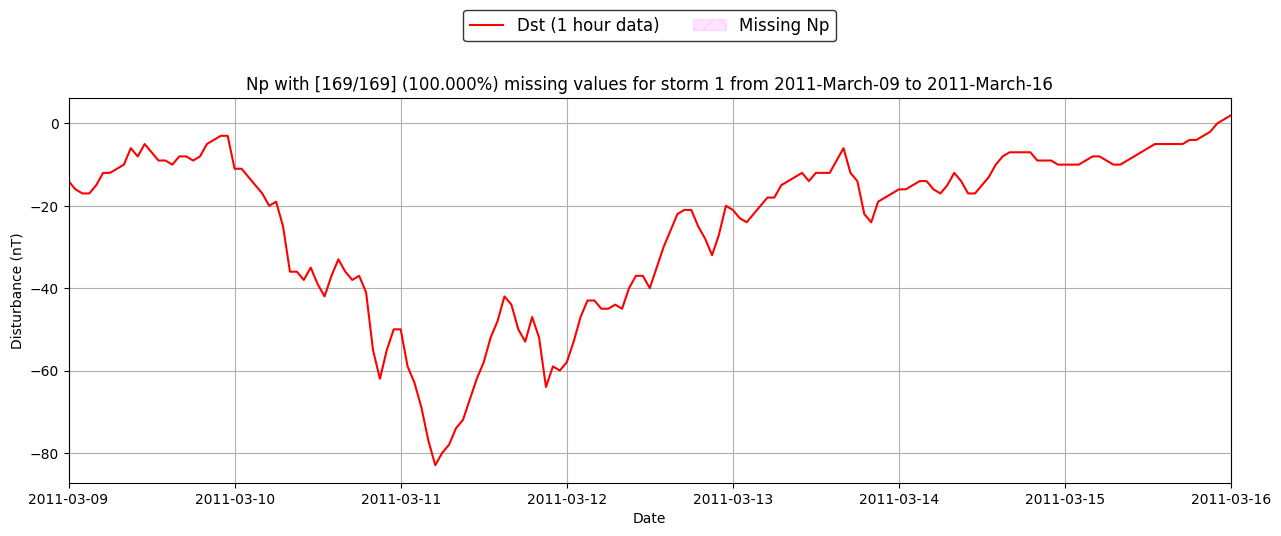

There are ACE missing values in Storm 2 from 2011 May 26 to 2011 June 02
Np missing 131 values (77.515%)


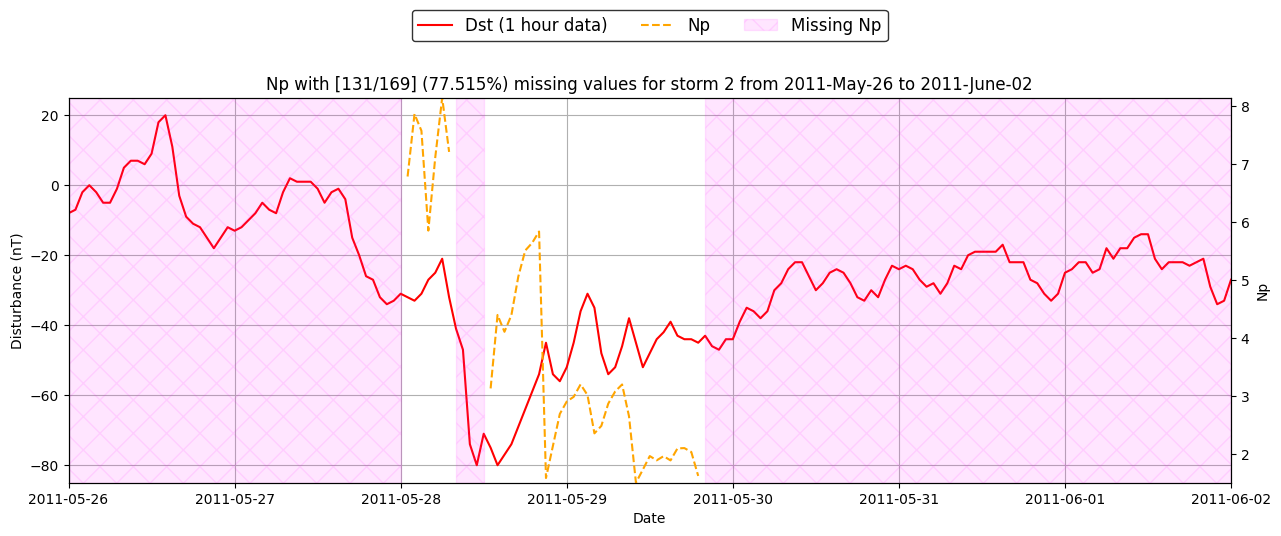

There are ACE missing values in Storm 3 from 2011 August 03 to 2011 August 11
Np missing 139 values (72.021%)


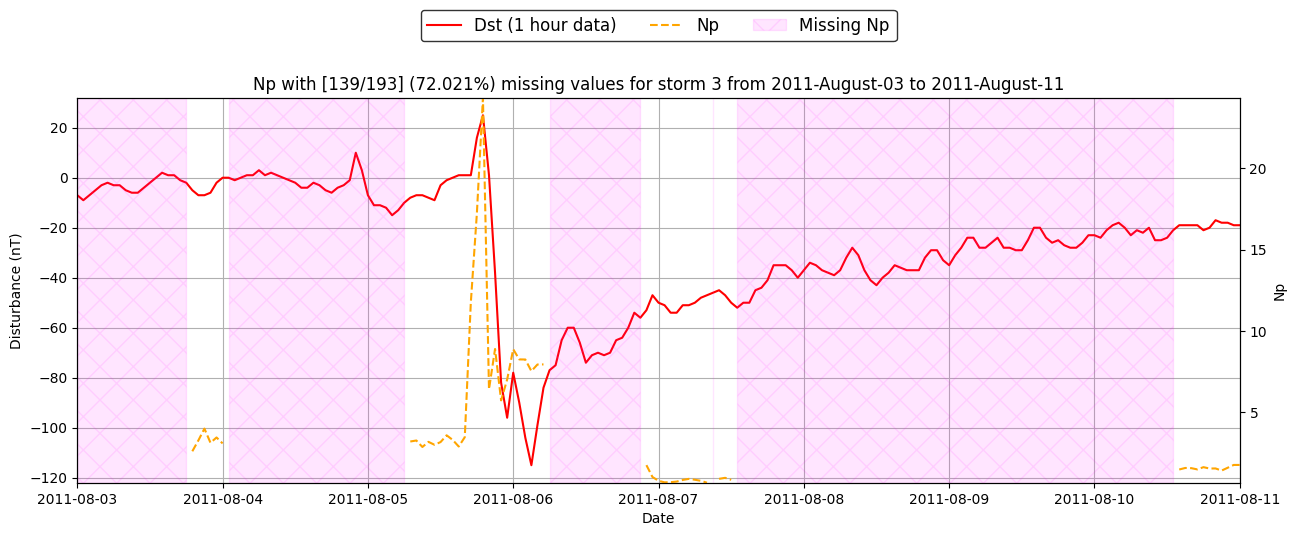

There are ACE missing values in Storm 4 from 2011 September 24 to 2011 October 02
Np missing 171 values (88.601%)


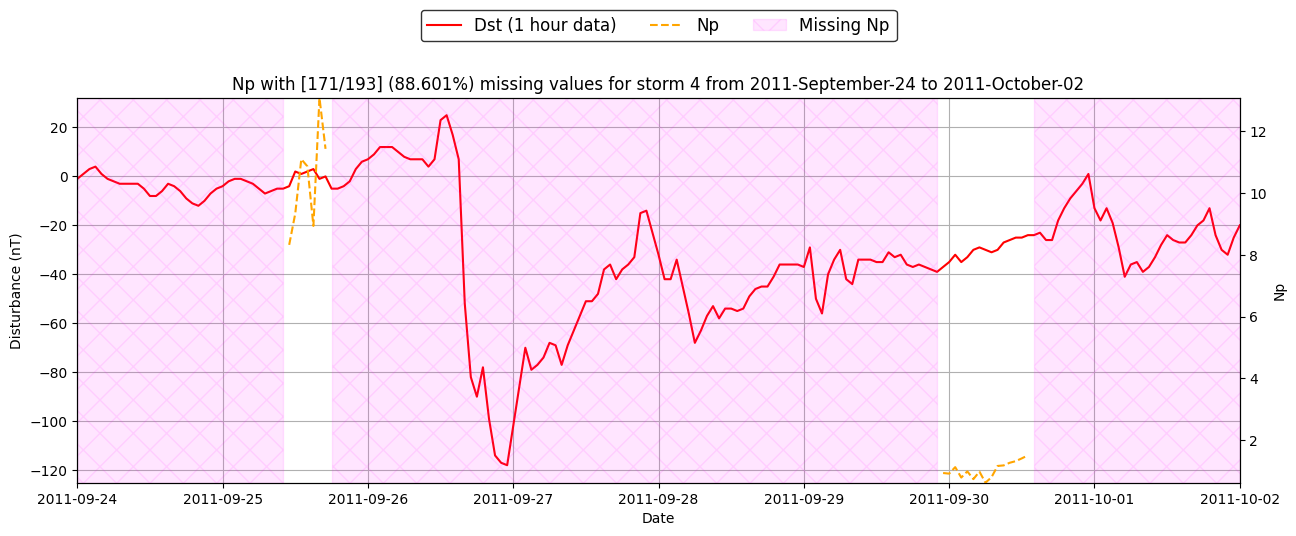

There are ACE missing values in Storm 5 from 2011 October 22 to 2011 October 30
Np missing 193 values (100.000%)


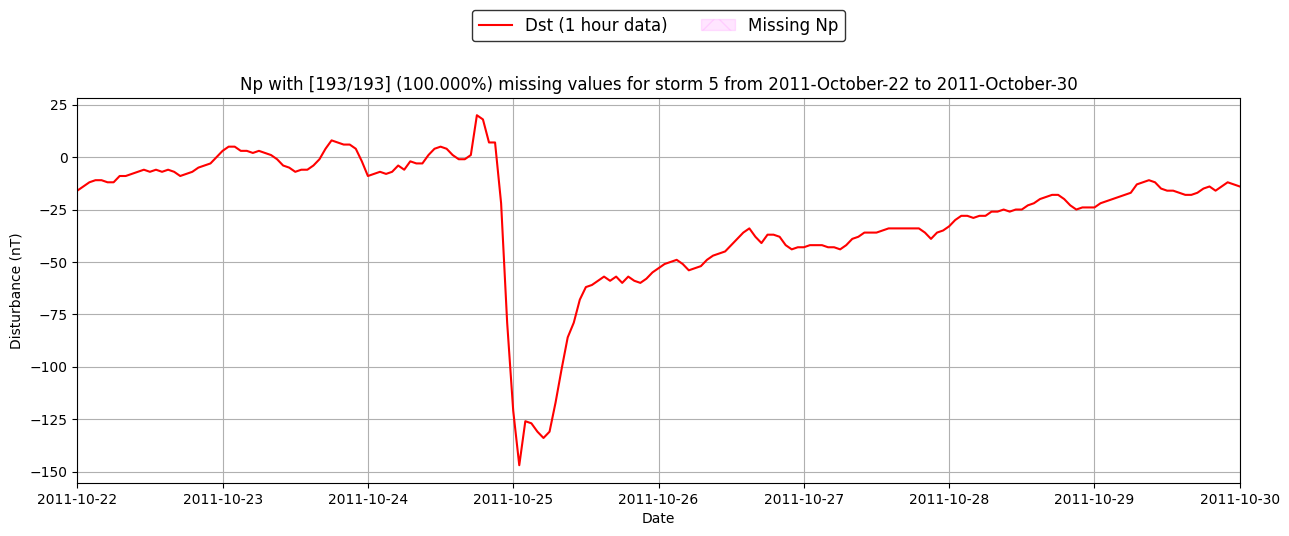

There are ACE missing values in Storm 6 from 2012 March 05 to 2012 March 14
Np missing 148 values (68.203%)


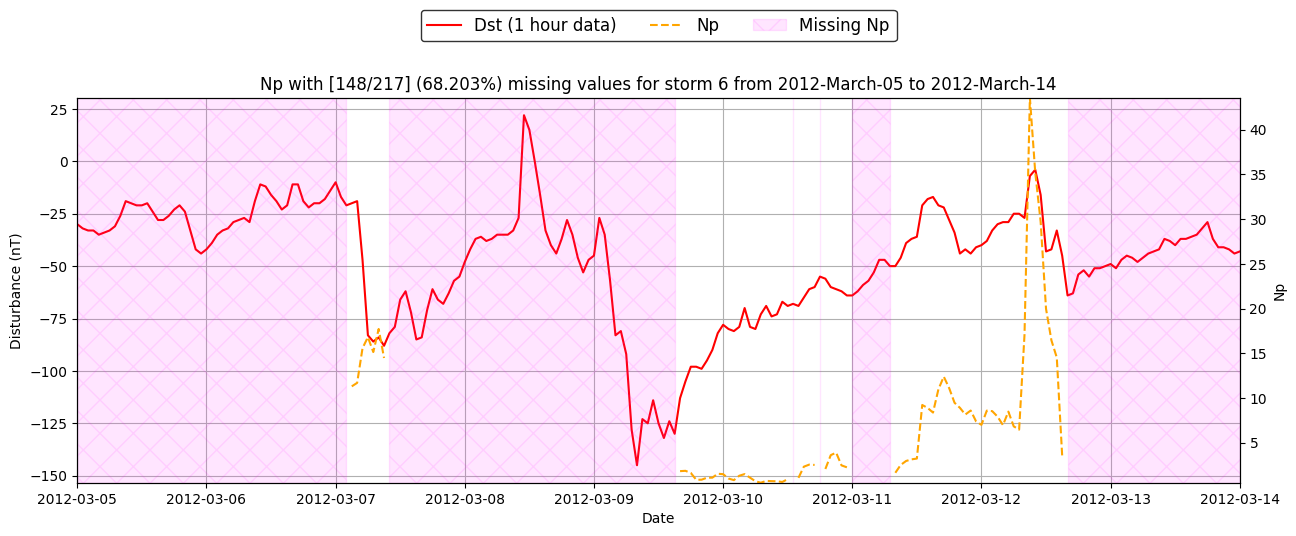

There are ACE missing values in Storm 7 from 2012 April 21 to 2012 April 29
Np missing 193 values (100.000%)


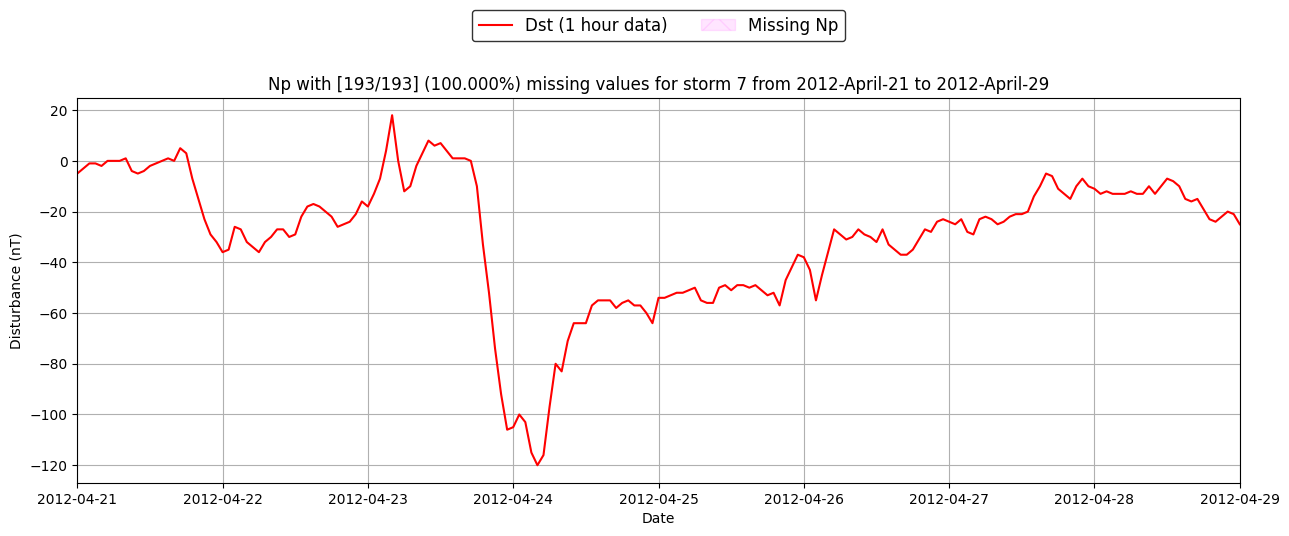

There are ACE missing values in Storm 8 from 2012 July 13 to 2012 July 21
Np missing 71 values (36.788%)


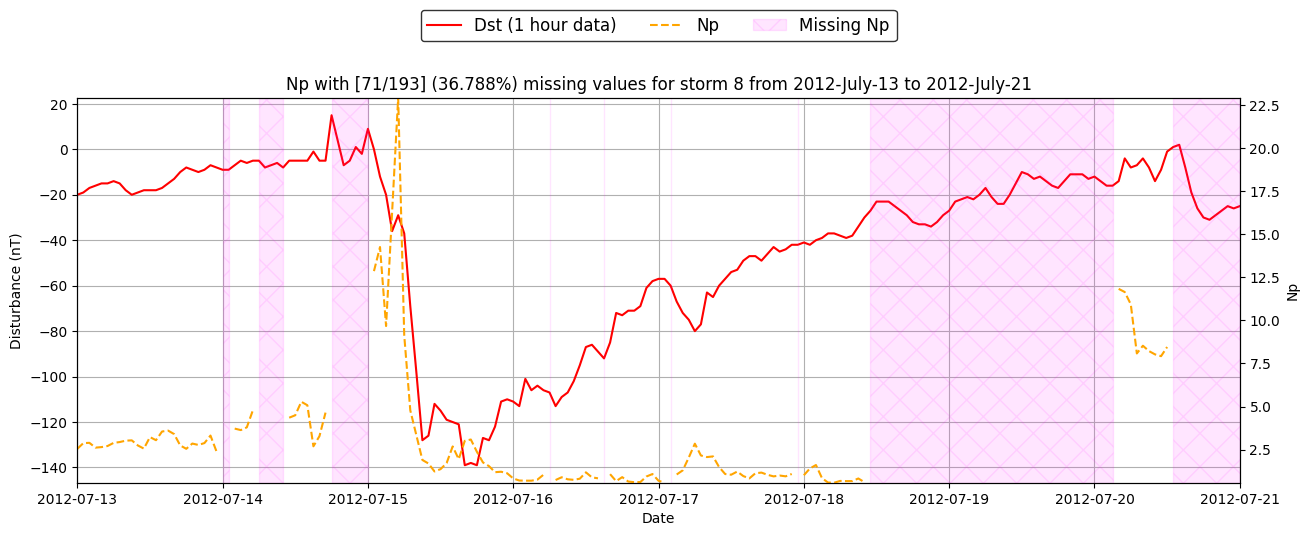

There are ACE missing values in Storm 9 from 2012 September 29 to 2012 October 18
Np missing 452 values (98.906%)


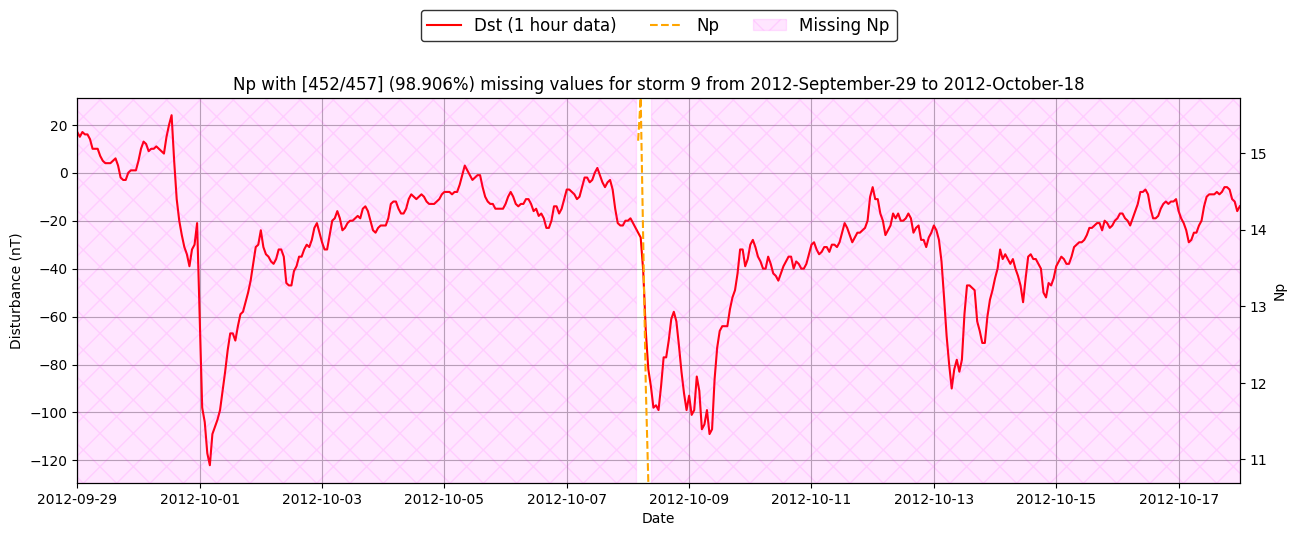

There are ACE missing values in Storm 10 from 2012 November 12 to 2012 November 19
Np missing 70 values (41.420%)


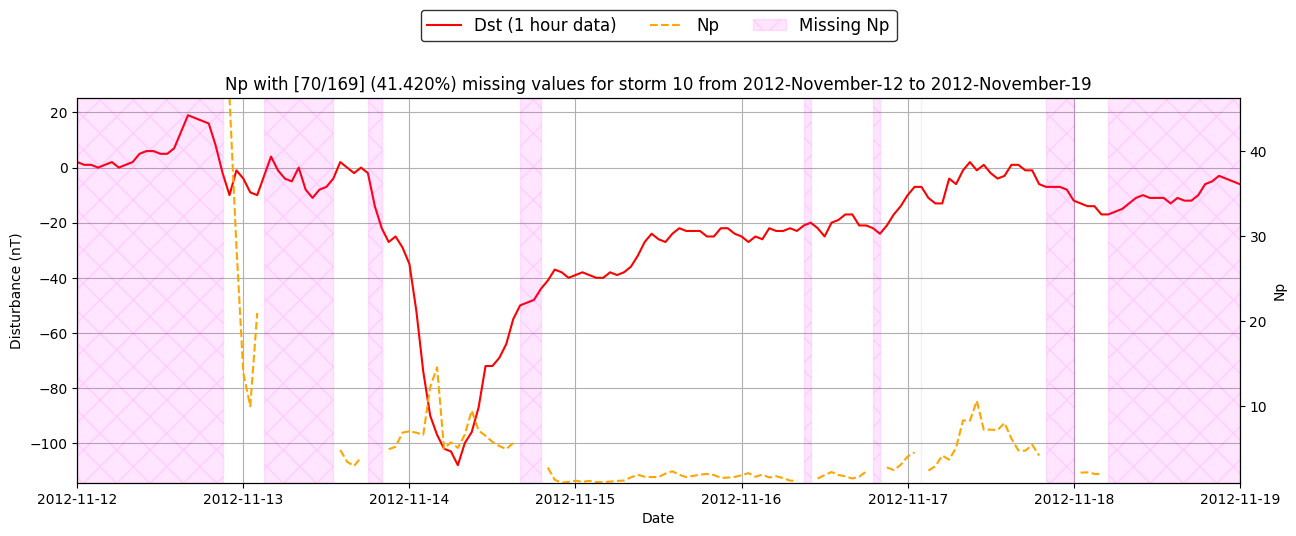

There are ACE missing values in Storm 11 from 2013 March 15 to 2013 March 23
Np missing 42 values (21.762%)


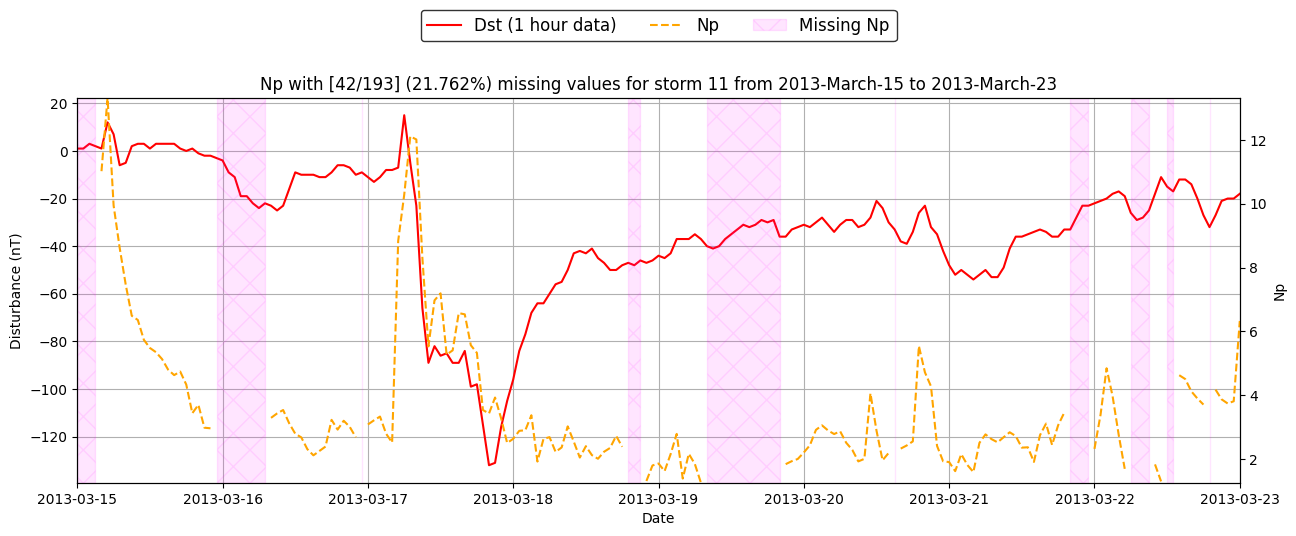

Storm 12 from 2013 May 30 to 2013 June 06 has no missing values


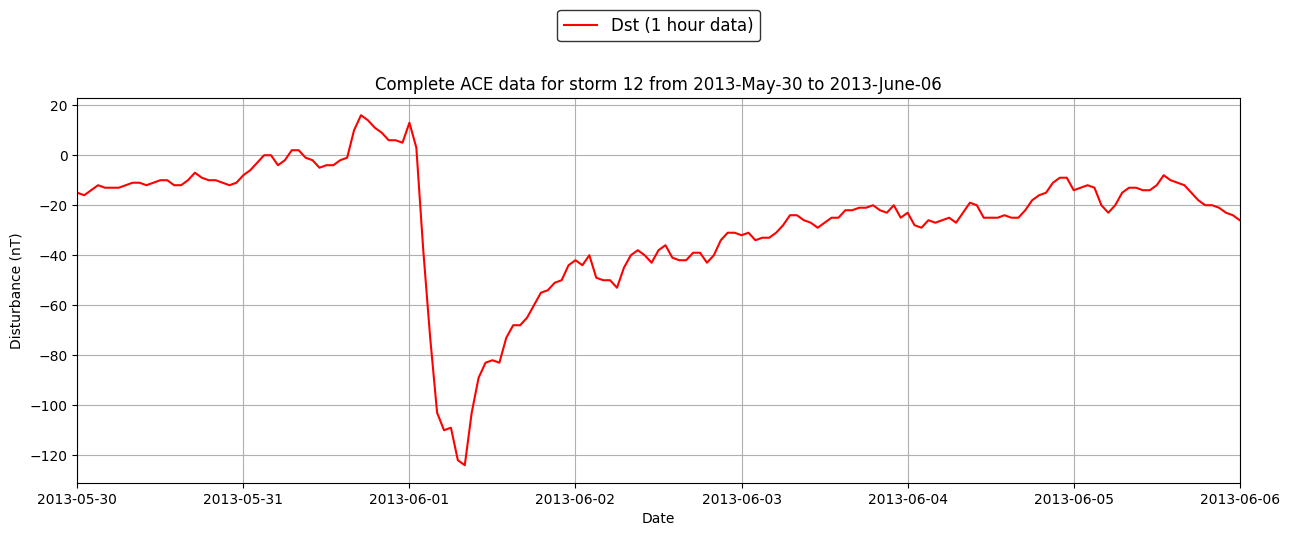

There are ACE missing values in Storm 13 from 2013 June 27 to 2013 July 04
Np missing 10 values (5.917%)


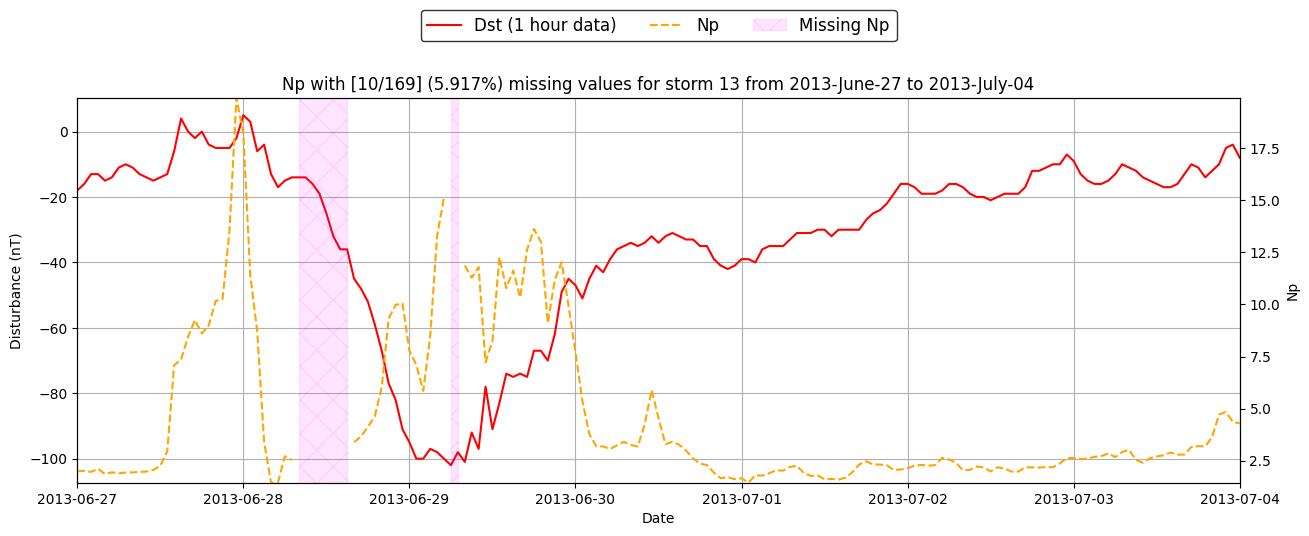

There are ACE missing values in Storm 14 from 2014 February 17 to 2014 March 05
Np missing 138 values (35.844%)


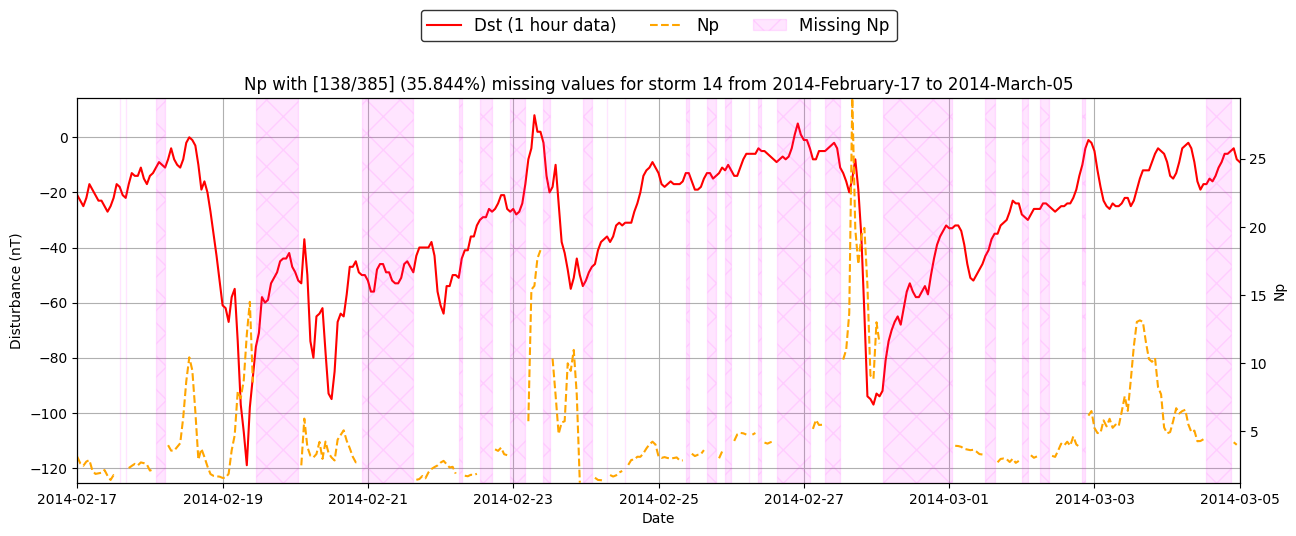

There are ACE missing values in Storm 15 from 2014 April 10 to 2014 April 17
Np missing 102 values (60.355%)


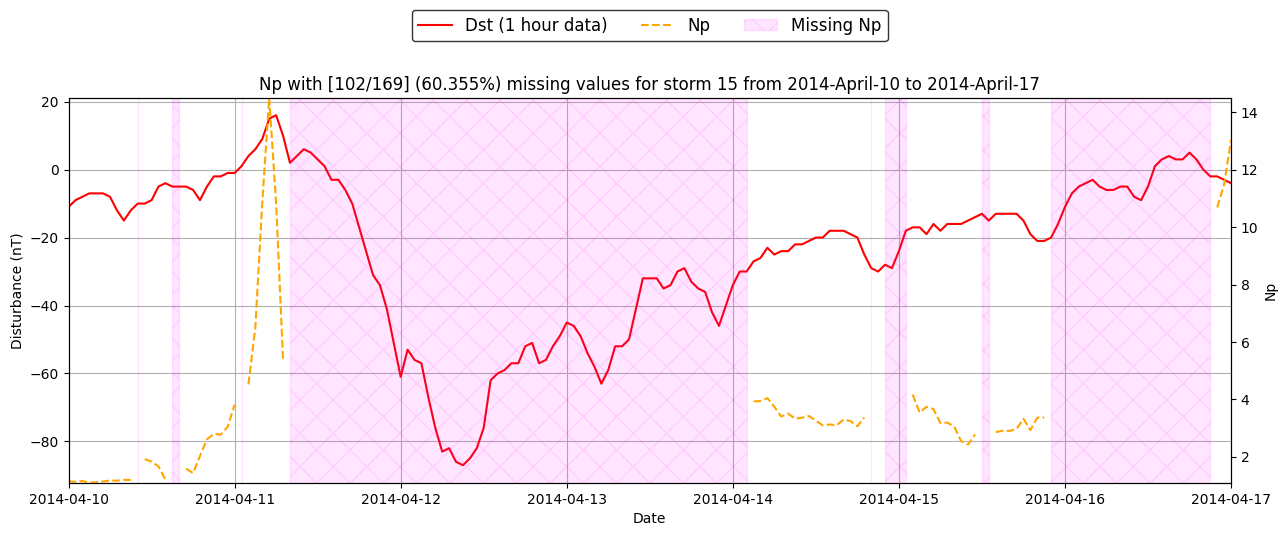

There are ACE missing values in Storm 16 from 2014 September 10 to 2014 September 17
Np missing 24 values (14.201%)


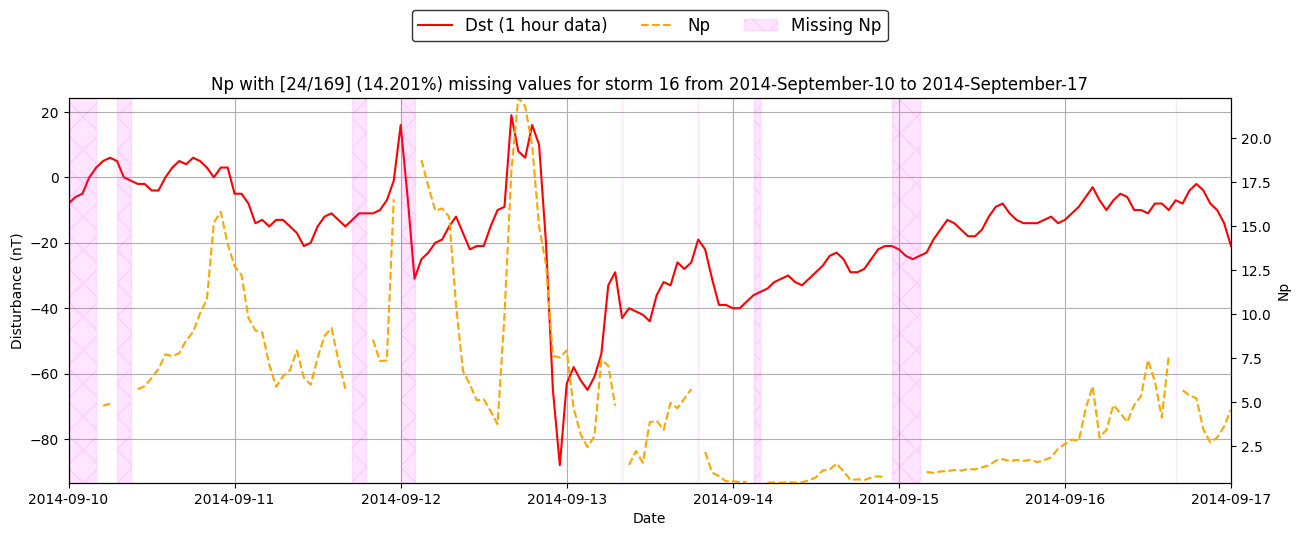

There are ACE missing values in Storm 17 from 2015 January 05 to 2015 January 12
Np missing 93 values (55.030%)


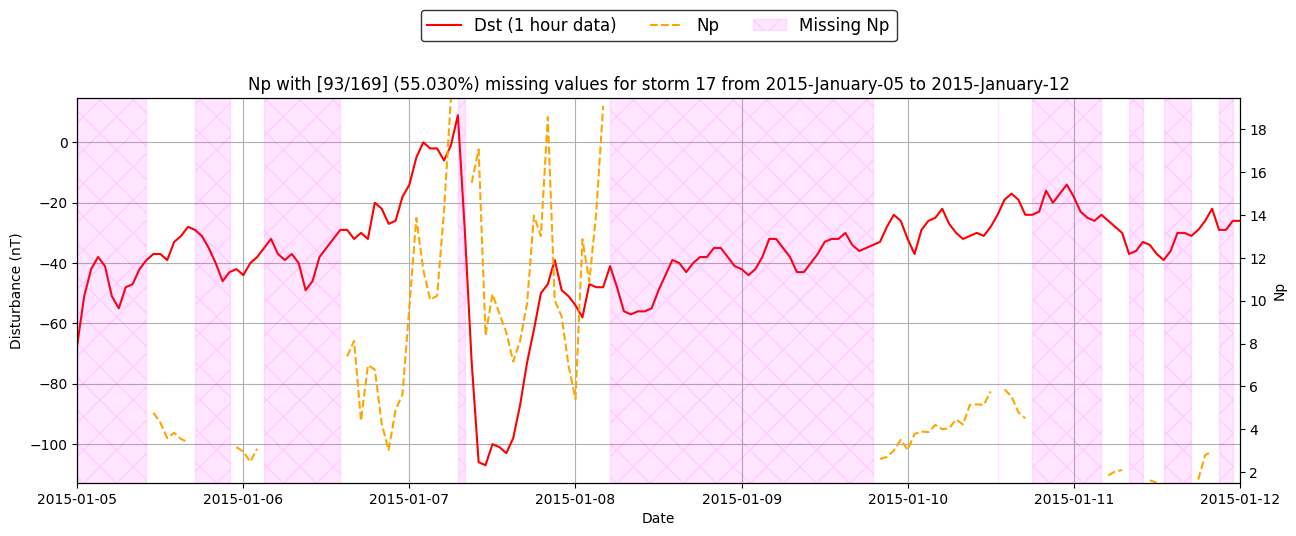

There are ACE missing values in Storm 18 from 2015 March 15 to 2015 March 23
Np missing 70 values (36.269%)


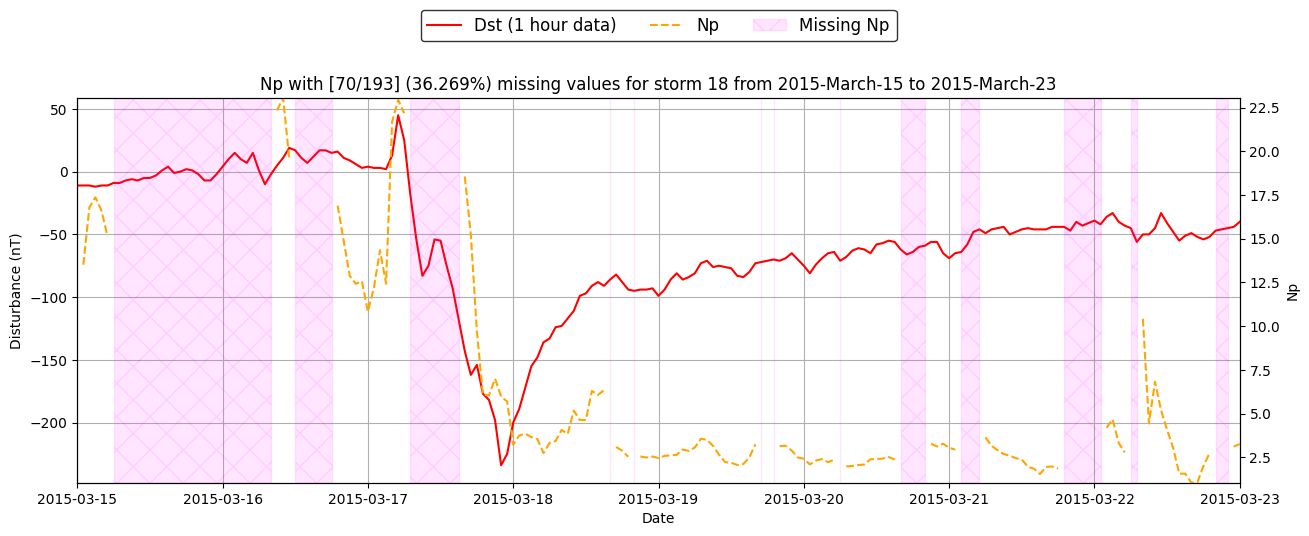

There are ACE missing values in Storm 19 from 2015 June 20 to 2015 June 30
Np missing 79 values (32.780%)


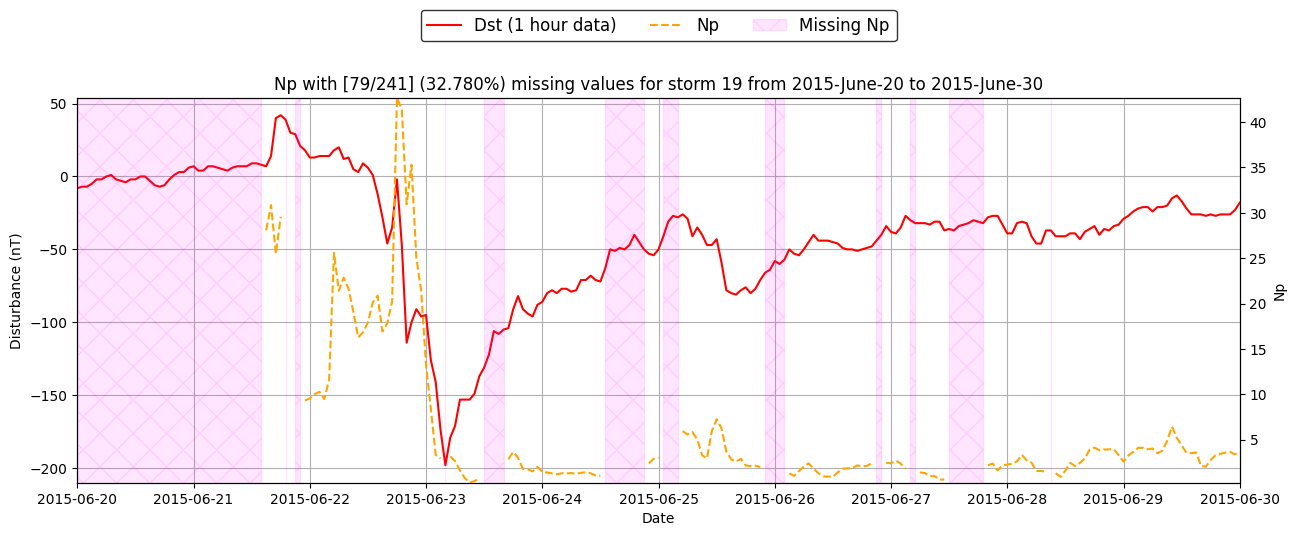

There are ACE missing values in Storm 20 from 2015 August 14 to 2015 August 21
Np missing 45 values (26.627%)


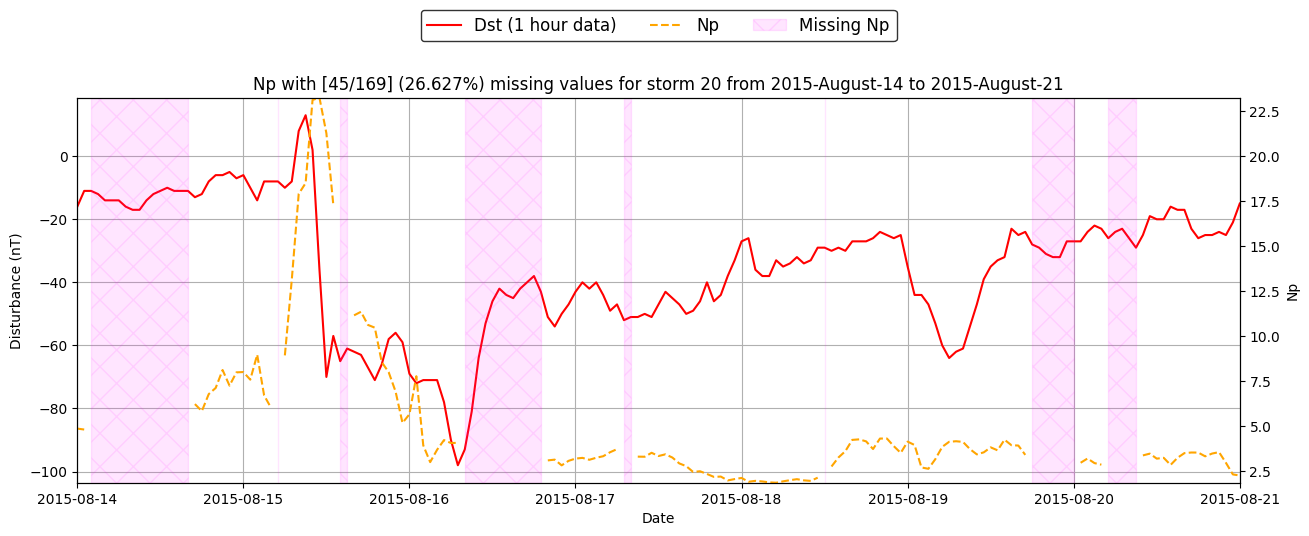

There are ACE missing values in Storm 21 from 2015 August 25 to 2015 September 02
Np missing 36 values (18.653%)


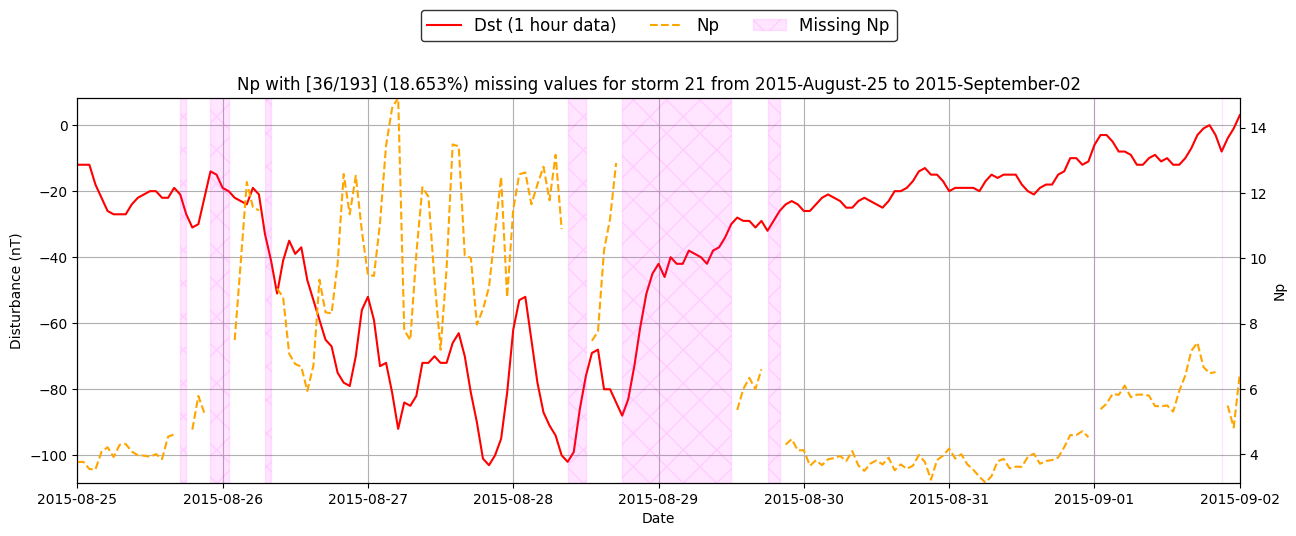

There are ACE missing values in Storm 22 from 2015 September 06 to 2015 September 16
Np missing 44 values (18.257%)


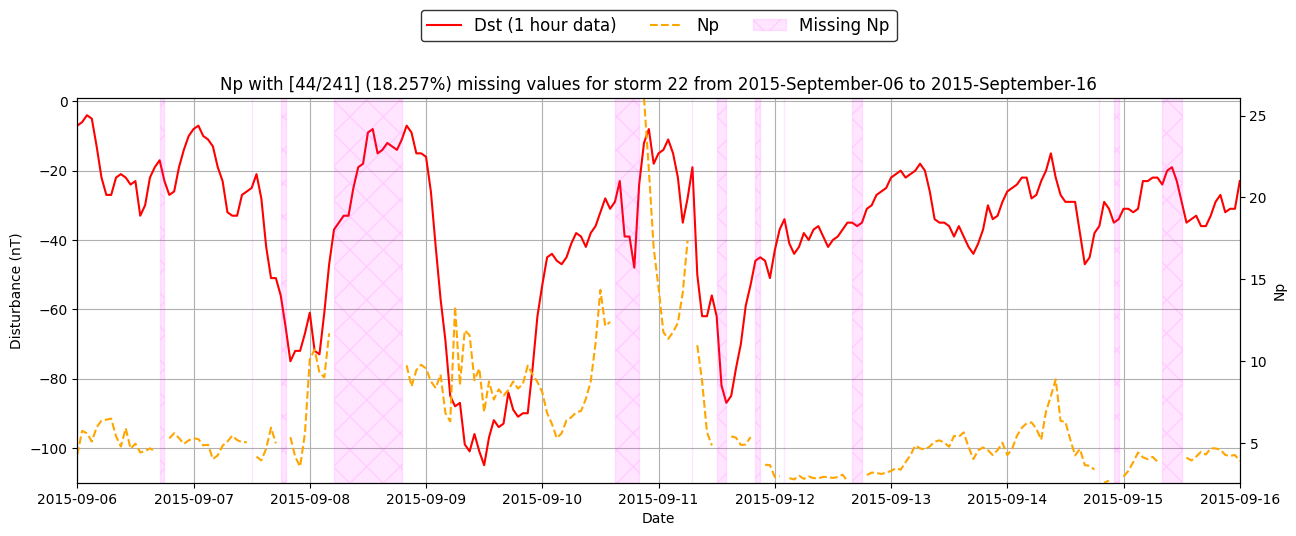

There are ACE missing values in Storm 23 from 2015 October 05 to 2015 October 13
Np missing 12 values (6.218%)


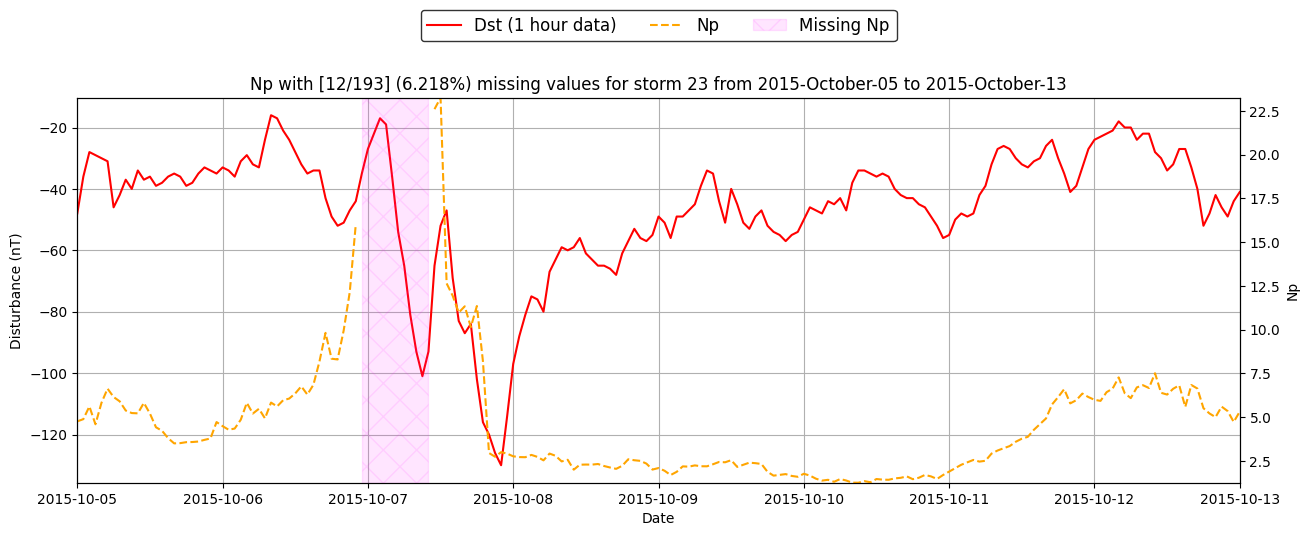

There are ACE missing values in Storm 24 from 2015 December 18 to 2015 December 26
Np missing 31 values (16.062%)


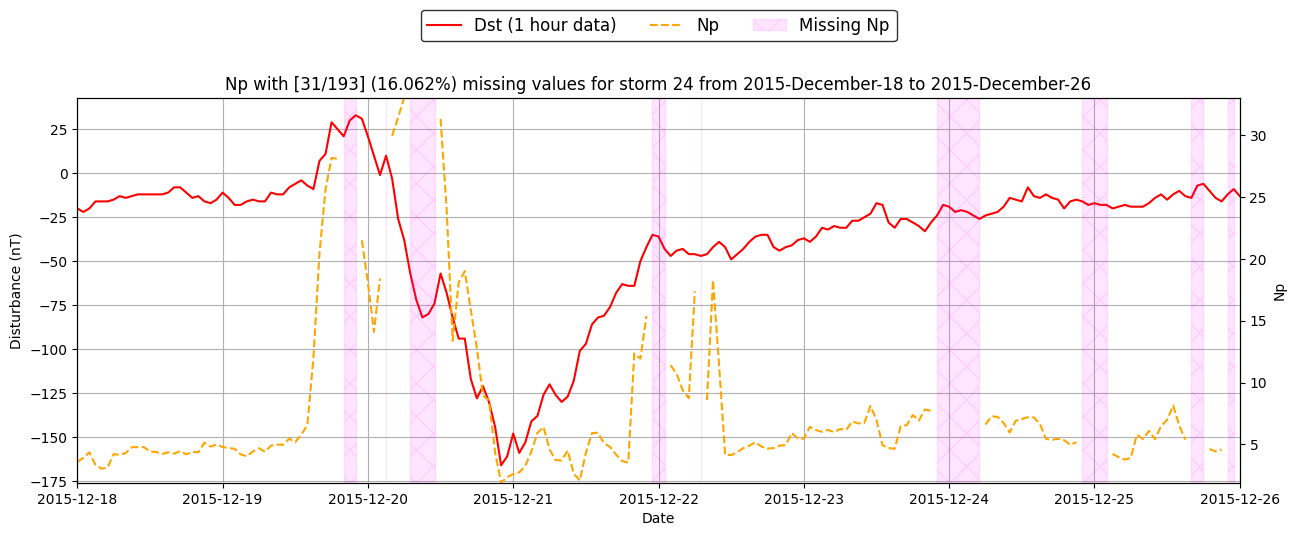

There are ACE missing values in Storm 25 from 2015 December 29 to 2016 January 06
Np missing 62 values (31.633%)


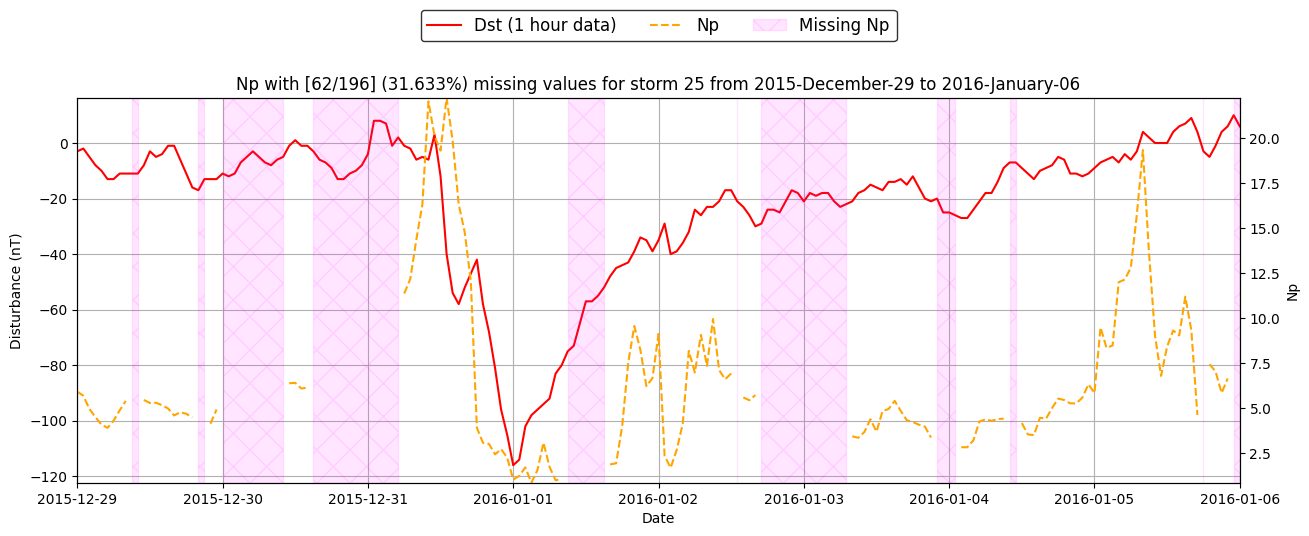

There are ACE missing values in Storm 26 from 2016 January 18 to 2016 January 25
Np missing 142 values (84.024%)


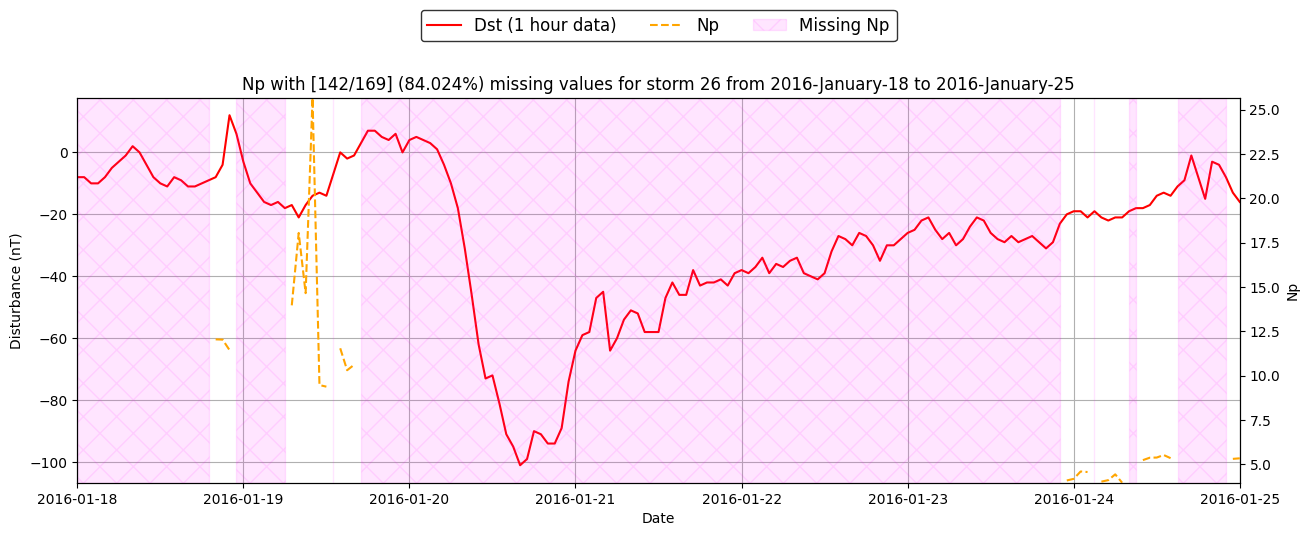

There are ACE missing values in Storm 27 from 2016 March 04 to 2016 March 12
Np missing 113 values (58.549%)


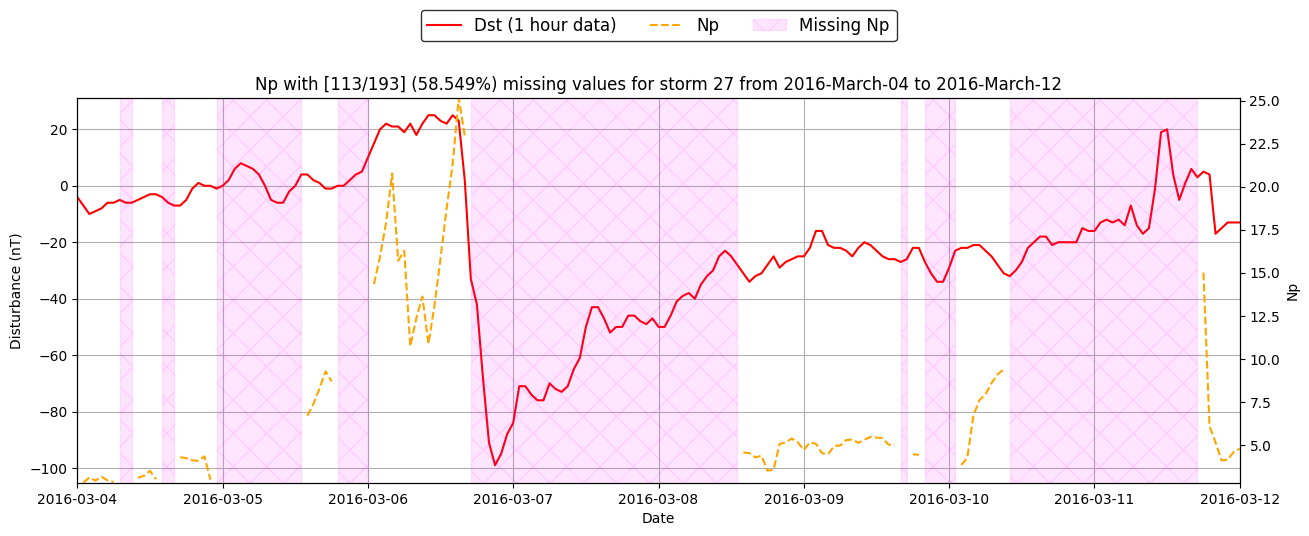

There are ACE missing values in Storm 28 from 2016 May 06 to 2016 May 14
Np missing 36 values (18.653%)


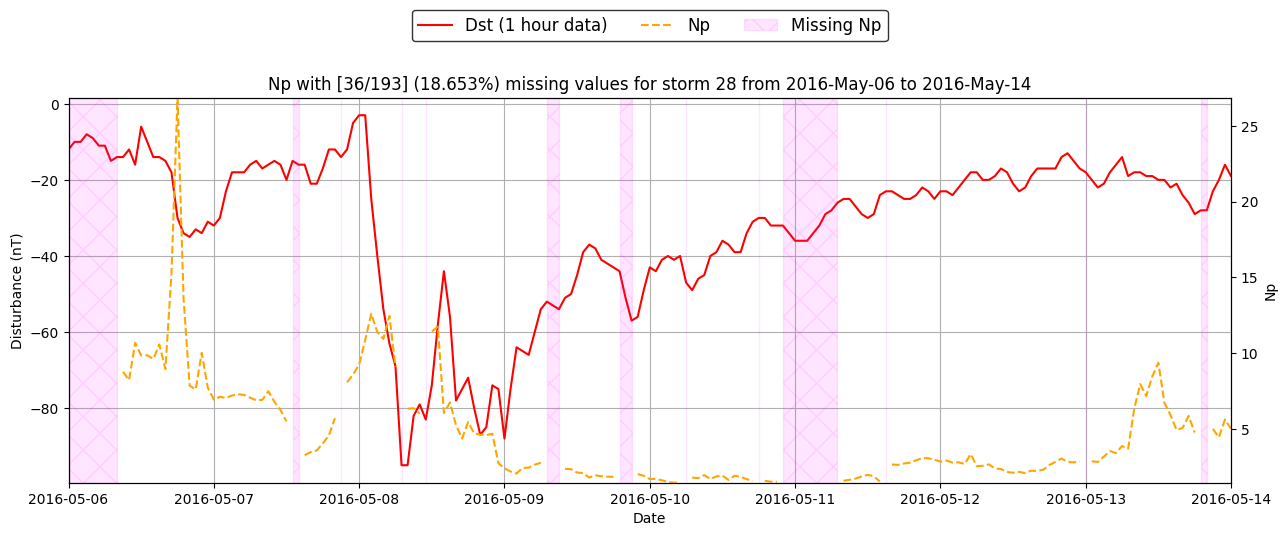

There are ACE missing values in Storm 29 from 2016 October 11 to 2016 October 19
Np missing 9 values (4.663%)


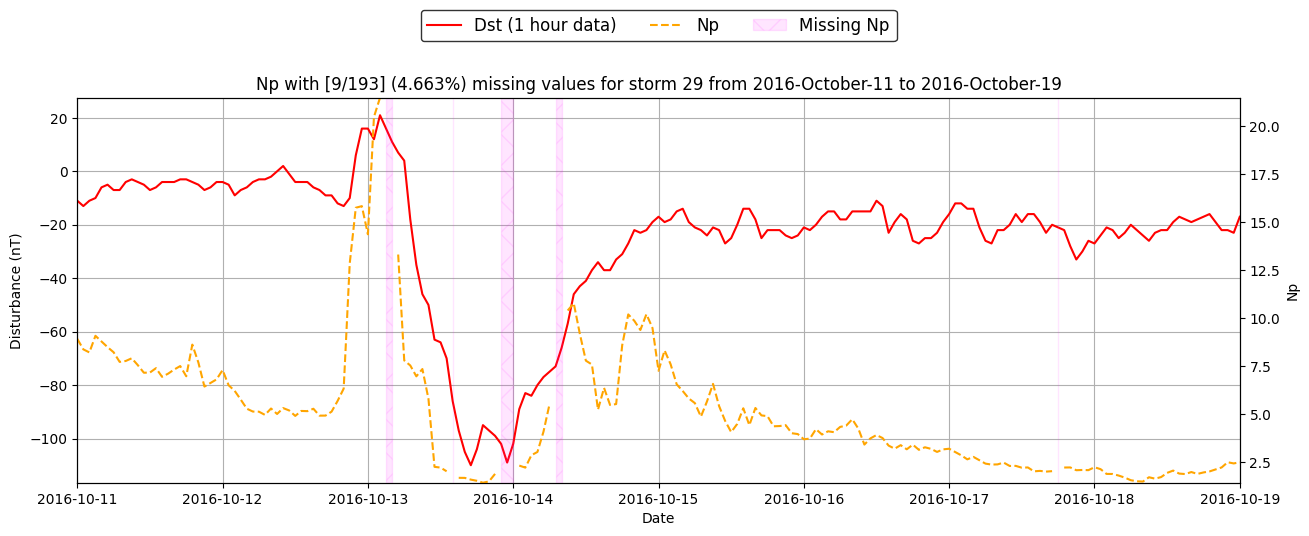

Complete ACE Storms [1/29]
Missing percentages for each storm: [np.float64(100.0), np.float64(77.51479289940828), np.float64(72.02072538860104), np.float64(88.60103626943005), np.float64(100.0), np.float64(68.20276497695853), np.float64(100.0), np.float64(36.787564766839374), np.float64(98.90590809628009), np.float64(41.42011834319527), np.float64(21.761658031088082), 0, np.float64(5.9171597633136095), np.float64(35.84415584415584), np.float64(60.35502958579882), np.float64(14.201183431952662), np.float64(55.02958579881657), np.float64(36.26943005181347), np.float64(32.780082987551864), np.float64(26.627218934911244), np.float64(18.65284974093264), np.float64(18.25726141078838), np.float64(6.217616580310881), np.float64(16.06217616580311), np.float64(31.63265306122449), np.float64(84.02366863905326), np.float64(58.549222797927456), np.float64(18.65284974093264), np.float64(4.66321243523316)]
Average missing percentage across all storms: 45.826%
Maximum missing percentage across all sto

In [13]:
PLOT_COMPLETE_STORMS = True
PLOT_INCOMPLETE_STORMS = True

missing_percentages = []

valid_ace_train_storms = 0
for start_date, end_date, storm_index in STORMS_MISSING_PERIOD_REGRESSION:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    storm = ace_data[sd:ed].copy()
    if storm[ace_columns].isna().sum().sum() == 0:
        print(f'Storm {storm_index} from {sd.strftime("%Y %B %d")} to {ed.strftime("%Y %B %d")} has no missing values')
        valid_ace_train_storms += 1
        if not PLOT_COMPLETE_STORMS:
            continue
            
        plot_storm(dst_kyoto, storm, None, sd, ed, storm_index)
        missing_percentages.append(0)
        
    else:
        print(f'There are ACE missing values in Storm {storm_index} from {sd.strftime("%Y %B %d")} to {ed.strftime("%Y %B %d")}')
        if not PLOT_INCOMPLETE_STORMS:
            continue
            
        col = storm[ace_columns].isna().sum().sort_values(ascending=False).index[0]
        print(f'{col} missing {storm[col].isna().sum()} values ({storm[col].isna().sum() / len(storm[col]) * 100:.3f}%)')
        plot_storm(dst_kyoto, storm, col, sd, ed, storm_index)
        missing_percentages.append(storm[col].isna().sum() / len(storm[col]) * 100)
        
    
print(f'Complete ACE Storms [{valid_ace_train_storms}/{len(STORMS_MISSING_PERIOD_REGRESSION)}]')
print(f'Missing percentages for each storm: {missing_percentages}')
print(f'Average missing percentage across all storms: {np.mean(missing_percentages):.3f}%')
print(f'Maximum missing percentage across all storms: {np.max(missing_percentages):.3f}%')